# Clasificacion de Malformacion de Arnold-Chiari Tipo I
## Notebook 03 — Entrenamiento CNN con K-Fold

Entrena DenseNet121, EfficientNetB0 y ResNet50V2 usando
K-Fold estratificado (k=5) sobre `data/cropped/`.

| Arquitectura   | Params totales | Base preentrenada |
|----------------|---------------|-------------------|
| DenseNet121    | ~7 M          | ImageNet (CheXNet) |
| EfficientNetB0 | ~4 M          | ImageNet           |
| ResNet50V2     | ~23 M         | ImageNet           |

**Correciones vs version anterior:** K-Fold en lugar de split fijo,
cabeza Dense(32), LR fase 2 = 1e-6, descongelar solo 10 capas,
Dropout=0.5, L2=1e-3. CLAHE integrado en la carga de imagen.

In [1]:
import os, json, warnings, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE        = Path('.').resolve()
DIR_CRP_CH  = BASE / 'data' / 'cropped' / 'chiari'
DIR_CRP_NO  = BASE / 'data' / 'cropped' / 'normal'
DIR_MODELS  = BASE / 'models'
DIR_REPORTS = BASE / 'reports'
DIR_FIGURES = BASE / 'reports' / 'figures'
DIR_GRADCAM = BASE / 'reports' / 'gradcam'
for d in [DIR_MODELS, DIR_FIGURES, DIR_GRADCAM]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'IMG_SHAPE'    : (224, 224, 3),
    'BATCH_SIZE'   : 8,
    'K_FOLDS'      : 5,
    'EPOCHS_F1'    : 40,
    'LR_F1'        : 1e-3,
    'EPOCHS_F2'    : 30,
    'LR_F2'        : 1e-6,
    'UNFREEZE_TOP' : 10,
    'PATIENCE'     : 15,
    'SEED'         : SEED,
}

print(f'TensorFlow  : {tf.__version__}')
print(f'K_FOLDS     : {CFG["K_FOLDS"]}')
print(f'IMG_SHAPE   : {CFG["IMG_SHAPE"]}')

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow  : 2.20.0
K_FOLDS     : 5
IMG_SHAPE   : (224, 224, 3)


## 1. Carga del dataset

In [2]:
def listar(carpeta):
    exts = {'.jpg', '.jpeg', '.png'}
    imgs = []
    for ext in exts:
        imgs += list(Path(carpeta).glob(f'*{ext}'))
        imgs += list(Path(carpeta).glob(f'*{ext.upper()}'))
    return sorted(set(imgs))

normal_paths = listar(DIR_CRP_NO)
chiari_paths = listar(DIR_CRP_CH)

X_paths = np.array([str(p) for p in normal_paths + chiari_paths])
y       = np.array([0]*len(normal_paths) + [1]*len(chiari_paths))

print(f'Normal  : {len(normal_paths)}')
print(f'Chiari  : {len(chiari_paths)}')
print(f'Total   : {len(X_paths)}')
print(f'K={CFG["K_FOLDS"]} folds → ~{len(X_paths)//CFG["K_FOLDS"]} imgs por fold en val')

Normal  : 30
Chiari  : 30
Total   : 60
K=5 folds → ~12 imgs por fold en val


## 2. Funciones de carga y augmentacion

`cargar_imagen` aplica CLAHE directamente (integrado con el preprocesamiento).
La augmentacion solo ocurre en el generador de entrenamiento.

In [3]:
def cargar_imagen(ruta):
    arr = np.array(Image.open(ruta).convert('L'), dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr = clahe.apply(arr)
    arr_f = np.array(
        Image.fromarray(arr).resize(CFG['IMG_SHAPE'][:2], Image.LANCZOS),
        dtype=np.float32
    ) / 255.0
    return np.stack([arr_f, arr_f, arr_f], axis=-1)


def augmentar(img):
    if np.random.rand() > 0.5:
        img = np.fliplr(img)
    if np.random.rand() > 0.5:
        img = np.clip(img * np.random.uniform(0.90, 1.10), 0, 1)
    if np.random.rand() > 0.6:
        img = np.clip(
            img + np.random.normal(0, 0.008, img.shape).astype(np.float32),
            0, 1
        )
    return img


class FoldGen(keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size, augment=False, shuffle=True):
        self.paths   = np.array(paths)
        self.labels  = np.array(labels)
        self.bs      = batch_size
        self.augment = augment
        self.idx     = np.arange(len(self.paths))
        if shuffle:
            np.random.shuffle(self.idx)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.bs))

    def __getitem__(self, i):
        bi = self.idx[i*self.bs:(i+1)*self.bs]
        X  = np.array([
            augmentar(cargar_imagen(self.paths[j])) if self.augment
            else cargar_imagen(self.paths[j])
            for j in bi
        ], dtype=np.float32)
        return X, self.labels[bi].astype(np.float32)

    def on_epoch_end(self):
        np.random.shuffle(self.idx)


print('Generadores listos')

Generadores listos


## 3. Construccion de modelos

Cabeza simplificada: GAP → BN → Dense(32, L2=1e-3) → Dropout(0.5) → Sigmoid.
Reduces parametros entrenables vs Dense(128)+Dense(64) → menos overfitting
con dataset pequeño.

In [4]:
def construir_modelo(arquitectura):
    if arquitectura == 'DenseNet121':
        base = DenseNet121(include_top=False, weights='imagenet',
                           input_shape=CFG['IMG_SHAPE'])
    elif arquitectura == 'EfficientNetB0':
        base = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=CFG['IMG_SHAPE'])
    elif arquitectura == 'ResNet50V2':
        base = ResNet50V2(include_top=False, weights='imagenet',
                         input_shape=CFG['IMG_SHAPE'])
    base.trainable = False

    inp = keras.Input(shape=CFG['IMG_SHAPE'])
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(32, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    modelo = Model(inp, out, name=arquitectura)
    total  = modelo.count_params()
    train  = sum(np.prod(v.shape) for v in modelo.trainable_variables)
    print(f'  {arquitectura:<18}: {total:>10,} params | {train:>8,} entrenables')
    return modelo, base

print('Parametros por arquitectura (Fase 1 — base congelada):')
for arch in ['DenseNet121', 'EfficientNetB0', 'ResNet50V2']:
    m, _ = construir_modelo(arch)
    del m

Parametros por arquitectura (Fase 1 — base congelada):
  DenseNet121       :  7,074,433 params |   34,881 entrenables
  EfficientNetB0    :  4,095,716 params |   43,585 entrenables
  ResNet50V2        : 23,638,593 params |   69,697 entrenables


## 4. K-Fold Cross-Validation

In [5]:
def entrenar_fold(arch, X_tr, y_tr, X_val, y_val, fold_n):
    tf.keras.backend.clear_session()
    modelo, base = construir_modelo(arch)

    gen_tr  = FoldGen(X_tr,  y_tr,  CFG['BATCH_SIZE'], augment=True,  shuffle=True)
    gen_val = FoldGen(X_val, y_val, CFG['BATCH_SIZE'], augment=False, shuffle=False)

    cbs = [
        EarlyStopping(monitor='val_auc', patience=CFG['PATIENCE'],
                      mode='max', restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-8, verbose=0),
    ]

    def compilar(lr):
        modelo.compile(
            optimizer=keras.optimizers.Adam(lr),
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )

    # Fase 1 — solo cabeza
    compilar(CFG['LR_F1'])
    modelo.fit(gen_tr, validation_data=gen_val,
               epochs=CFG['EPOCHS_F1'], callbacks=cbs, verbose=0)

    # Fase 2 — fine-tuning conservador (10 capas, LR 1e-6)
    base.trainable = True
    for layer in base.layers[:-CFG['UNFREEZE_TOP']]:
        layer.trainable = False
    compilar(CFG['LR_F2'])
    modelo.fit(gen_tr, validation_data=gen_val,
               epochs=CFG['EPOCHS_F2'], callbacks=cbs, verbose=0)

    y_prob = modelo.predict(gen_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    res = {
        'fold'         : fold_n,
        'auc'          : round(roc_auc_score(y_val, y_prob), 4),
        'f1'           : round(f1_score(y_val, y_pred, zero_division=0), 4),
        'accuracy'     : round((tp+tn)/len(y_val), 4),
        'sensibilidad' : round(tp/(tp+fn+1e-8), 4),
        'especificidad': round(tn/(tn+fp+1e-8), 4),
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'y_val' : y_val.tolist(),
        'y_prob': y_prob.tolist(),
    }
    print(f'    Fold {fold_n}: AUC={res["auc"]:.3f}  F1={res["f1"]:.3f}'
          f'  Sens={res["sensibilidad"]:.3f}  Espec={res["especificidad"]:.3f}  FN={fn}')
    return modelo, res

print('Funcion entrenar_fold() lista')

Funcion entrenar_fold() lista


In [6]:
ARQUITECTURAS    = ['DenseNet121', 'EfficientNetB0', 'ResNet50V2']
skf              = StratifiedKFold(n_splits=CFG['K_FOLDS'], shuffle=True,
                                   random_state=CFG['SEED'])
resultados_kfold = {}
mejores_modelos  = {}

for arch in ARQUITECTURAS:
    print(f'\n{"="*55}')
    print(f'  {arch}')
    print(f'{"="*55}')
    fold_results = []
    mejor_auc, mejor_modelo = -1, None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_paths, y), start=1):
        modelo, res = entrenar_fold(
            arch,
            X_paths[tr_idx], y[tr_idx],
            X_paths[val_idx], y[val_idx],
            fold
        )
        fold_results.append(res)
        if res['auc'] > mejor_auc:
            mejor_auc, mejor_modelo = res['auc'], modelo

    resultados_kfold[arch] = fold_results
    mejores_modelos[arch]  = mejor_modelo

    df_f = pd.DataFrame(fold_results)
    print(f'\n  Resumen {arch}:')
    for m in ['auc', 'f1', 'sensibilidad', 'especificidad']:
        print(f'    {m:<16}: {df_f[m].mean():.3f} +/- {df_f[m].std():.3f}')

print('\nK-Fold completado')


  DenseNet121
  DenseNet121       :  7,074,433 params |   34,881 entrenables
    Fold 1: AUC=0.389  F1=0.462  Sens=0.500  Espec=0.333  FN=3
  DenseNet121       :  7,074,433 params |   34,881 entrenables
    Fold 2: AUC=0.556  F1=0.667  Sens=0.833  Espec=0.333  FN=1
  DenseNet121       :  7,074,433 params |   34,881 entrenables
    Fold 3: AUC=0.583  F1=0.714  Sens=0.833  Espec=0.500  FN=1
  DenseNet121       :  7,074,433 params |   34,881 entrenables
    Fold 4: AUC=0.694  F1=0.222  Sens=0.167  Espec=0.667  FN=5
  DenseNet121       :  7,074,433 params |   34,881 entrenables
    Fold 5: AUC=0.306  F1=0.667  Sens=1.000  Espec=0.000  FN=0

  Resumen DenseNet121:
    auc             : 0.506 +/- 0.156
    f1              : 0.546 +/- 0.206
    sensibilidad    : 0.667 +/- 0.333
    especificidad   : 0.367 +/- 0.247

  EfficientNetB0
  EfficientNetB0    :  4,095,716 params |   43,585 entrenables
    Fold 1: AUC=0.361  F1=0.000  Sens=0.000  Espec=1.000  FN=6
  EfficientNetB0    :  4,095,716 pa

## 5. Comparacion de resultados

COMPARACION K-FOLD — Media +/- Std  (k=5 folds)
                            auc               f1         accuracy     sensibilidad    especificidad
Arquitectura                                                                                       
DenseNet121     0.506 +/- 0.156  0.546 +/- 0.206  0.517 +/- 0.109  0.667 +/- 0.333  0.367 +/- 0.247
EfficientNetB0  0.478 +/- 0.137  0.120 +/- 0.268  0.533 +/- 0.075  0.100 +/- 0.224  0.967 +/- 0.075
ResNet50V2      0.456 +/- 0.272  0.486 +/- 0.173  0.483 +/- 0.160  0.500 +/- 0.204  0.467 +/- 0.139


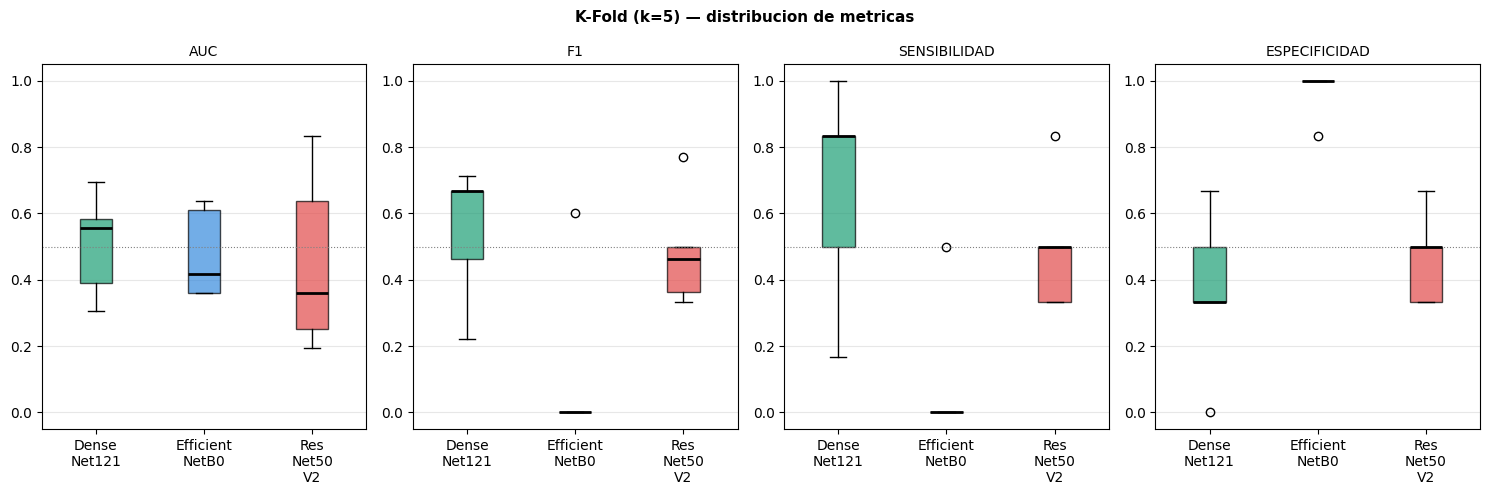

In [7]:
metricas = ['auc', 'f1', 'accuracy', 'sensibilidad', 'especificidad']
colores  = {'DenseNet121': '#1D9E75', 'EfficientNetB0': '#378ADD',
            'ResNet50V2': '#E24B4A'}

# Tabla resumen
filas = []
for arch in ARQUITECTURAS:
    df_f = pd.DataFrame(resultados_kfold[arch])
    fila = {'Arquitectura': arch}
    for m in metricas:
        fila[m] = f'{df_f[m].mean():.3f} +/- {df_f[m].std():.3f}'
    filas.append(fila)

df_comp = pd.DataFrame(filas).set_index('Arquitectura')
print('COMPARACION K-FOLD — Media +/- Std  (k=5 folds)')
print('=' * 70)
print(df_comp.to_string())

# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle(f'K-Fold (k={CFG["K_FOLDS"]}) — distribucion de metricas',
             fontsize=11, fontweight='bold')

for ax, metrica in zip(axes, ['auc', 'f1', 'sensibilidad', 'especificidad']):
    datos = {arch: [r[metrica] for r in resultados_kfold[arch]]
             for arch in ARQUITECTURAS}
    bp = ax.boxplot(list(datos.values()),
                    labels=[a.replace('Net', '\nNet').replace('V2', '\nV2')
                            for a in ARQUITECTURAS],
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, arch in zip(bp['boxes'], ARQUITECTURAS):
        patch.set_facecolor(colores[arch]); patch.set_alpha(0.7)
    ax.set_title(metrica.upper(), fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(DIR_FIGURES / 'kfold_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

AUC medio por arquitectura:
  DenseNet121       : 0.5056  <-- MEJOR
  EfficientNetB0    : 0.4778
  ResNet50V2        : 0.4555


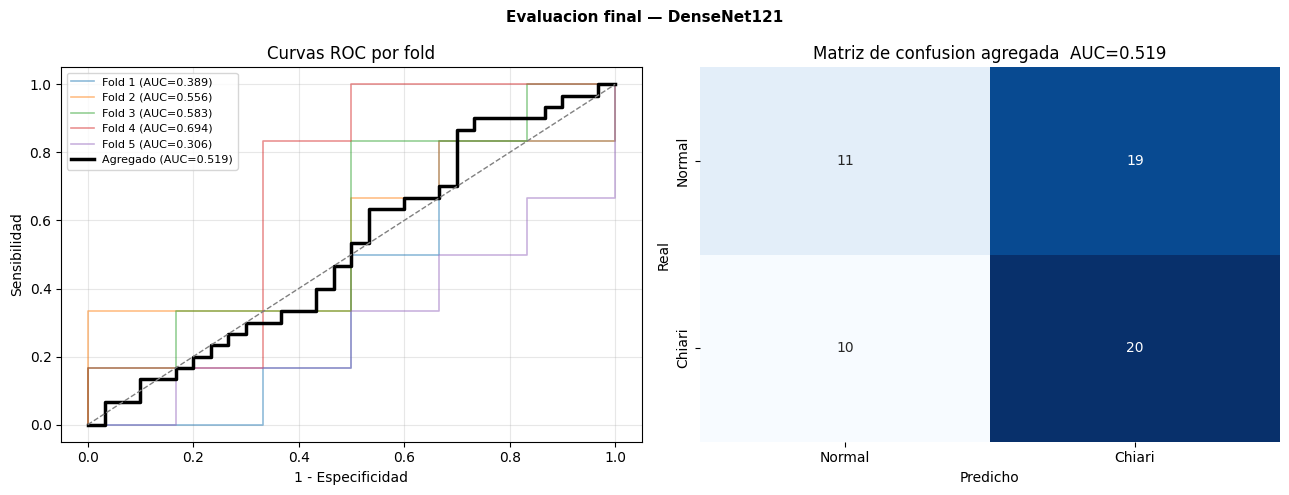

Sensibilidad : 0.6667
Especificidad: 0.3667
FN           : 10  (Chiari no detectados)


In [8]:
# Mejor arquitectura por AUC medio
auc_medios = {arch: pd.DataFrame(resultados_kfold[arch])['auc'].mean()
              for arch in ARQUITECTURAS}
mejor_arch = max(auc_medios, key=auc_medios.get)

print('AUC medio por arquitectura:')
for arch, auc in sorted(auc_medios.items(), key=lambda x: -x[1]):
    m = '  <-- MEJOR' if arch == mejor_arch else ''
    print(f'  {arch:<18}: {auc:.4f}{m}')

# Curvas ROC + matriz de confusion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Evaluacion final — {mejor_arch}', fontsize=11, fontweight='bold')

all_y_true, all_y_prob = [], []
for r in resultados_kfold[mejor_arch]:
    fpr, tpr, _ = roc_curve(r['y_val'], r['y_prob'])
    axes[0].plot(fpr, tpr, alpha=0.5, lw=1.2,
                 label=f'Fold {r["fold"]} (AUC={r["auc"]:.3f})')
    all_y_true.extend(r['y_val'])
    all_y_prob.extend(r['y_prob'])

fpr_all, tpr_all, _ = roc_curve(all_y_true, all_y_prob)
auc_all = roc_auc_score(all_y_true, all_y_prob)
axes[0].plot(fpr_all, tpr_all, 'k-', lw=2.5,
             label=f'Agregado (AUC={auc_all:.3f})')
axes[0].plot([0,1],[0,1], '--', color='gray', lw=1)
axes[0].set_xlabel('1 - Especificidad'); axes[0].set_ylabel('Sensibilidad')
axes[0].set_title('Curvas ROC por fold'); axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

y_pred_all = (np.array(all_y_prob) >= 0.5).astype(int)
cm = confusion_matrix(all_y_true, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Chiari'],
            yticklabels=['Normal','Chiari'], cbar=False)
axes[1].set_title(f'Matriz de confusion agregada  AUC={auc_all:.3f}')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig(str(DIR_FIGURES / f'roc_{mejor_arch}.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Sensibilidad : {tp/(tp+fn+1e-8):.4f}')
print(f'Especificidad: {tn/(tn+fp+1e-8):.4f}')
print(f'FN           : {fn}  (Chiari no detectados)')

## 6. Grad-CAM — validacion clinica interna

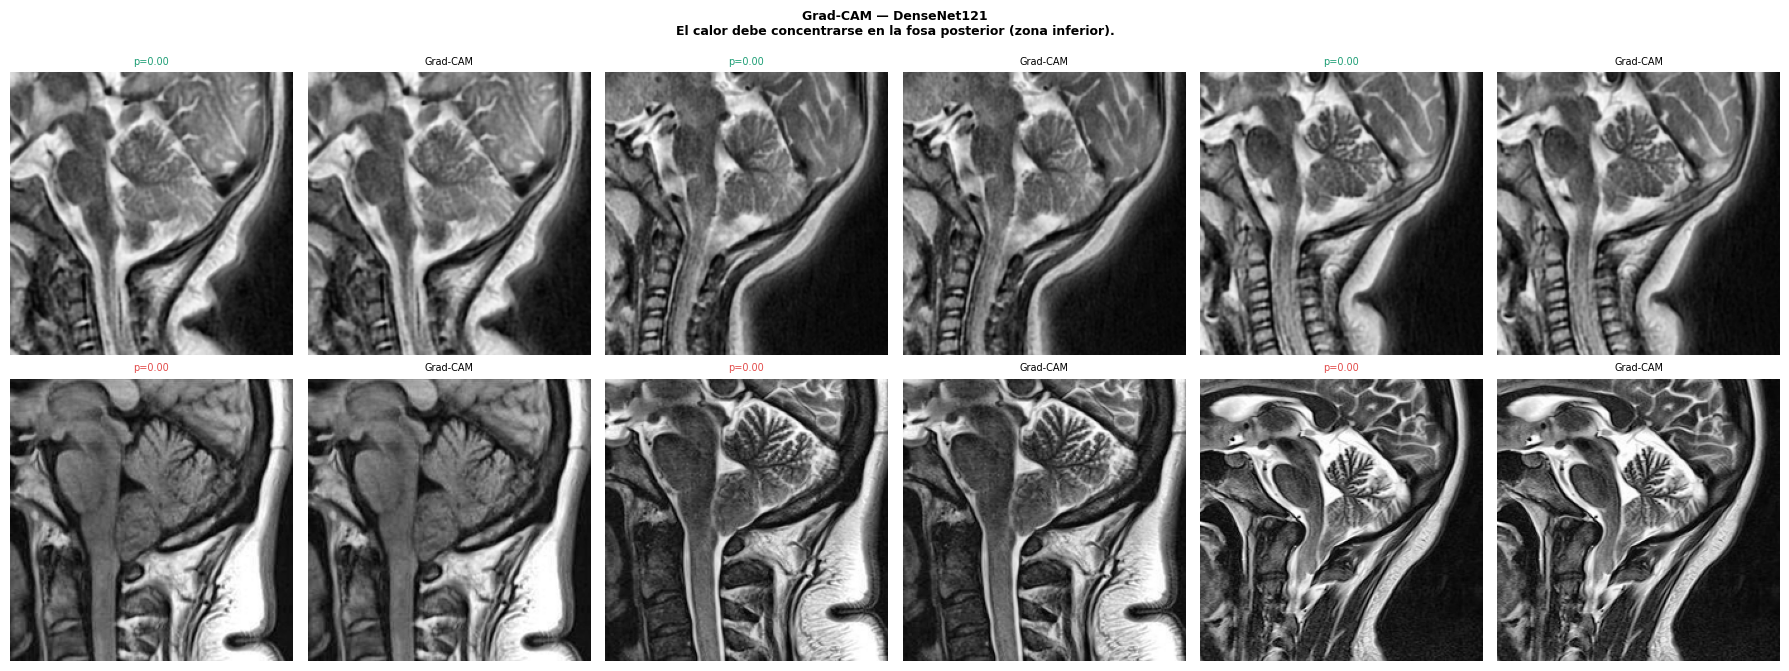

In [9]:
LAST_CONV = {
    'DenseNet121'   : 'conv5_block16_concat',
    'EfficientNetB0': 'top_conv',
    'ResNet50V2'    : 'post_relu',
}

def make_gradcam(modelo, img_array, last_conv):
    gm = Model(inputs=modelo.inputs,
               outputs=[modelo.get_layer(last_conv).output, modelo.output])
    with tf.GradientTape() as tape:
        co, preds = gm(img_array)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, co)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(co[0] @ pooled[..., tf.newaxis]).numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap, float(preds[0, 0])


last_conv    = LAST_CONV[mejor_arch]
mejor_modelo = mejores_modelos[mejor_arch]

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle(
    f'Grad-CAM — {mejor_arch}\n'
    'El calor debe concentrarse en la fosa posterior (zona inferior).',
    fontsize=9, fontweight='bold'
)

for row_idx, (clase_id, clase_str, color) in enumerate([
    (0, 'Normal', '#1D9E75'), (1, 'Chiari', '#E24B4A')
]):
    rutas = X_paths[y == clase_id][:3]
    for ci, ruta in enumerate(rutas):
        img    = cargar_imagen(ruta)
        img_in = np.expand_dims(img, 0)
        try:
            hm, prob = make_gradcam(mejor_modelo, img_in, last_conv)
            h, w     = img.shape[:2]
            hm_r     = cv2.resize(hm, (w, h))
            hm_c     = cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_JET)
            hm_c     = cv2.cvtColor(hm_c, cv2.COLOR_BGR2RGB)
            overlay  = cv2.addWeighted(np.uint8(img*255), 0.6, hm_c, 0.4, 0)
        except Exception:
            overlay, prob = np.uint8(img*255), 0.0

        pred = 'Chiari' if prob >= 0.5 else 'Normal'
        tc   = '#1D9E75' if pred == clase_str else '#E24B4A'
        axes[row_idx][ci*2].imshow(img[:,:,0], cmap='gray')
        axes[row_idx][ci*2].set_title(f'p={prob:.2f}', fontsize=7, color=tc)
        axes[row_idx][ci*2].axis('off')
        axes[row_idx][ci*2+1].imshow(overlay)
        axes[row_idx][ci*2+1].set_title('Grad-CAM', fontsize=7)
        axes[row_idx][ci*2+1].axis('off')
    axes[row_idx][0].set_ylabel(clase_str, fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(str(DIR_GRADCAM / f'gradcam_{mejor_arch}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Guardado del modelo y reporte

In [10]:
ruta_modelo = DIR_MODELS / f'chiari_{mejor_arch}_kfold.keras'
mejor_modelo.save(str(ruta_modelo))

reporte = {
    'fecha'         : datetime.now().isoformat(),
    'mejor_arch'    : mejor_arch,
    'auc_agregado'  : round(float(auc_all), 4),
    'metricas_kfold': {
        arch: {
            m: f'{pd.DataFrame(resultados_kfold[arch])[m].mean():.4f} '
               f'+/- {pd.DataFrame(resultados_kfold[arch])[m].std():.4f}'
            for m in ['auc', 'f1', 'sensibilidad', 'especificidad']
        }
        for arch in ARQUITECTURAS
    },
}
with open(DIR_REPORTS / 'resultados_kfold.json', 'w', encoding='utf-8') as f:
    json.dump(reporte, f, indent=2, ensure_ascii=False)

print('=' * 55)
print('  NOTEBOOK 03 COMPLETADO')
print('=' * 55)
print(f'  Mejor modelo  : {mejor_arch}')
print(f'  AUC agregado  : {auc_all:.4f}')
print(f'  Guardado en   : models/chiari_{mejor_arch}_kfold.keras')
print('=' * 55)

  NOTEBOOK 03 COMPLETADO
  Mejor modelo  : DenseNet121
  AUC agregado  : 0.5189
  Guardado en   : models/chiari_DenseNet121_kfold.keras
